# Development of a CNN Model with the Spectogram as it's input feature:

## Imports:

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [3]:
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


## Geral:

In [4]:
BATCH_SIZE = 32
SAMPLE_RATE = 16000
DURATION_SECONDS = 1
N_FFT = 2048
HOP_LENGTH = 512

AUDIO_SAMPLES = DURATION_SECONDS * SAMPLE_RATE

In [5]:
def load_audio(file_path):
    """Carrega um arquivo de áudio e o decodifica para um tensor."""
    audio_binary = tf.io.read_file(file_path)
    audio, _ = tf.audio.decode_wav(audio_binary, desired_channels=1)
    return tf.squeeze(audio, axis=-1)

def ensure_fixed_length(audio, desired_samples=AUDIO_SAMPLES):
    """Garante que o áudio tenha um comprimento fixo."""
    audio_shape = tf.shape(audio)[0]
    if audio_shape < desired_samples:
        padding = desired_samples - audio_shape
        audio = tf.pad(audio, [[0, padding]])
    elif audio_shape > desired_samples:
        audio = audio[:desired_samples]
    return audio

def get_spectrogram(audio):
    """Converte o áudio em um espectrograma."""
    stft = tf.signal.stft(audio, frame_length=N_FFT, frame_step=HOP_LENGTH)
    spectrogram = tf.abs(stft)
    spectrogram = tf.expand_dims(spectrogram, axis=-1)
    return spectrogram

def get_label(file_path, class_names):
    """Extrai o rótulo do caminho do arquivo."""
    parts = tf.strings.split(file_path, os.path.sep)
    return tf.where(parts[-2] == class_names)[0][0]

def process_path(file_path, class_names):
    """Função completa que combina todo o pré-processamento."""
    label = get_label(file_path, class_names)
    audio = load_audio(file_path)
    audio = ensure_fixed_length(audio)
    spectrogram = get_spectrogram(audio)
    return spectrogram, label

def create_dataset_from_dir(directory_path, shuffle=False):

    file_dataset = tf.data.Dataset.list_files(str(Path(directory_path) / '*' / '*.wav'), shuffle=shuffle)
    
    num_files = len(list(file_dataset))
    print(f"Encontrados {num_files} arquivos em: {directory_path}")

    dataset = file_dataset.map(lambda x: process_path(x, CLASS_NAMES), num_parallel_calls=tf.data.AUTOTUNE)
    
    dataset = dataset.cache()
    if shuffle:
        dataset = dataset.shuffle(buffer_size=1000)
    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(buffer_size=tf.data.AUTOTUNE)
    
    return dataset

## No Data Augmentation:

In [6]:
BASE_PATH = "../dataset/"

TRAIN_PATH = os.path.join(BASE_PATH, "train")
VAL_PATH = os.path.join(BASE_PATH, "validation")
TEST_PATH = os.path.join(BASE_PATH, "test")

In [7]:
CLASS_NAMES = np.array([item.name for item in Path(TRAIN_PATH).glob('*') if item.is_dir()])
    
print(f"Classes encontradas: {CLASS_NAMES}")
NUM_CLASSES = len(CLASS_NAMES)

Classes encontradas: ['on' 'off' 'go' '_unknown_' 'no' 'stop' '_silence_']


I0000 00:00:1758770627.209096   13523 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9368 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4070, pci bus id: 0000:01:00.0, compute capability: 8.9
2025-09-25 00:23:47.908331: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-09-25 00:23:48.085400: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Encontrados 19201 arquivos em: ../dataset/train
Encontrados 2391 arquivos em: ../dataset/validation
Encontrados 2890 arquivos em: ../dataset/test

Formato (shape) do lote de espectrogramas: (32, 28, 1025, 1)
Formato (shape) do lote de rótulos: (32,)


2025-09-25 00:23:48.442918: W tensorflow/core/kernels/data/cache_dataset_ops.cc:916] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


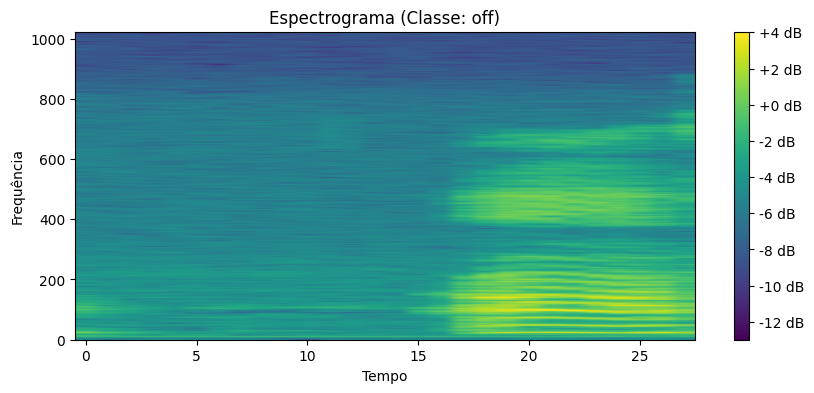

In [8]:
train_ds = create_dataset_from_dir(TRAIN_PATH, shuffle=True)
val_ds = create_dataset_from_dir(VAL_PATH)
test_ds = create_dataset_from_dir(TEST_PATH)

for spectrograms, labels in train_ds.take(1):
    input_shape = spectrograms.shape[1:]
    print(f"\nFormato (shape) do lote de espectrogramas: {spectrograms.shape}")
    print(f"Formato (shape) do lote de rótulos: {labels.shape}")
    
    plt.figure(figsize=(10, 4))
    plt.imshow(tf.math.log(spectrograms[0, :, :, 0] + 1e-6).numpy().T, aspect='auto', origin='lower')
    plt.title(f"Espectrograma (Classe: {CLASS_NAMES[labels[0]]})")
    plt.ylabel("Frequência")
    plt.xlabel("Tempo")
    plt.colorbar(format='%+2.0f dB')
    plt.show()
    break

### Training:

In [ ]:
model_espectograma = tf.keras.models.Sequential([
    tf.keras.layers.Input(input_shape),
    tf.keras.layers.Conv2D(32, kernel_size=(3, 3), padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.Conv2D(64, kernel_size=(3, 3), padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.Conv2D(128, kernel_size=(3, 3), padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(7, activation='softmax')
])

model_espectograma.summary()

In [ ]:
model_espectograma.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [ ]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
]

In [ ]:
history = model_espectograma.fit(train_ds, validation_data=val_ds, callbacks = callbacks, epochs=100, batch_size=32, verbose=1)

### Testing and Results:

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, 'o-', label='Acurácia de Treino')
plt.plot(epochs_range, val_acc, 'o-', label='Acurácia de Validação')
plt.title('Acurácia de Treino e Validação')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.grid(True)
plt.legend(loc='lower right')
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, 'o-', label='Loss de Treino')
plt.plot(epochs_range, val_loss, 'o-', label='Loss de Validação')
plt.title('Perda (Loss) de Treino e Validação')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.grid(True)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

In [ ]:
y_pred_probs = model_espectograma.predict(test_ds)

y_pred_indices = np.argmax(y_pred_probs, axis=1)

# Extract true labels from test_ds
y_true_indices = []
for _, labels in test_ds:
	y_true_indices.extend(labels.numpy())
y_true_indices = np.array(y_true_indices)

In [ ]:
print("--- Relatório de Classificação ---")

# Gera o relatório com precisão, recall, f1-score e suporte
# Usa os nomes das classes do label_encoder treinado anteriormente
report = classification_report(y_true_indices, y_pred_indices, target_names=CLASS_NAMES)

print(report)

In [ ]:
print("--- Matriz de Confusão ---")

# Calcula a matriz de confusão
cm = confusion_matrix(y_true_indices, y_pred_indices)

# Plota a matriz de confusão usando um heatmap do Seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,          # Mostra os números dentro das células
    fmt='d',             # Formata os números como inteiros
    cmap='Blues',        # Esquema de cores
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)

plt.title('Matriz de Confusão')
plt.ylabel('Label Verdadeiro')
plt.xlabel('Label Previsto')
plt.show()

## With Data Augmentation:

In [6]:
BASE_PATH = "../dataset_augmented/"

TRAIN_PATH = os.path.join(BASE_PATH, "train")
VAL_PATH = os.path.join(BASE_PATH, "validation")
TEST_PATH = os.path.join(BASE_PATH, "test")

In [7]:
CLASS_NAMES = np.array([item.name for item in Path(TRAIN_PATH).glob('*') if item.is_dir()])
    
print(f"Classes encontradas: {CLASS_NAMES}")
NUM_CLASSES = len(CLASS_NAMES)

Classes encontradas: ['on' 'off' 'go' '_unknown_' 'no' 'stop' '_silence_']


I0000 00:00:1758769334.685544    5293 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9820 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4070, pci bus id: 0000:01:00.0, compute capability: 8.9
2025-09-25 00:02:17.091440: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Encontrados 101370 arquivos em: ../dataset_augmented/train


2025-09-25 00:02:17.806723: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Encontrados 27355 arquivos em: ../dataset_augmented/validation
Encontrados 2890 arquivos em: ../dataset_augmented/test

Formato (shape) do lote de espectrogramas: (32, 28, 1025, 1)
Formato (shape) do lote de rótulos: (32,)


2025-09-25 00:02:18.150242: W tensorflow/core/kernels/data/cache_dataset_ops.cc:916] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


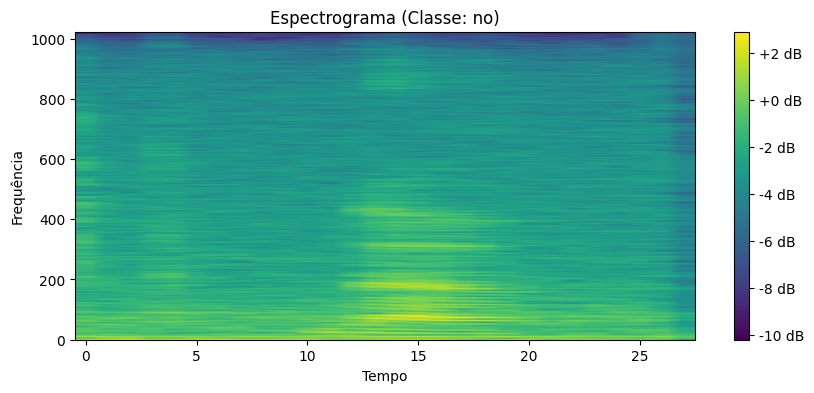

In [8]:
train_ds = create_dataset_from_dir(TRAIN_PATH, shuffle=True)
val_ds = create_dataset_from_dir(VAL_PATH)
test_ds = create_dataset_from_dir(TEST_PATH)

for spectrograms, labels in train_ds.take(1):
    input_shape = spectrograms.shape[1:]
    print(f"\nFormato (shape) do lote de espectrogramas: {spectrograms.shape}")
    print(f"Formato (shape) do lote de rótulos: {labels.shape}")
    
    plt.figure(figsize=(10, 4))
    plt.imshow(tf.math.log(spectrograms[0, :, :, 0] + 1e-6).numpy().T, aspect='auto', origin='lower')
    plt.title(f"Espectrograma (Classe: {CLASS_NAMES[labels[0]]})")
    plt.ylabel("Frequência")
    plt.xlabel("Tempo")
    plt.colorbar(format='%+2.0f dB')
    plt.show()
    break

### Training:

In [9]:
model_espectograma_aug = tf.keras.models.Sequential([
    tf.keras.layers.Input(input_shape),
    tf.keras.layers.Conv2D(64, kernel_size=(3, 3), padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.Conv2D(64, kernel_size=(3, 3), padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.Conv2D(128, kernel_size=(3, 3), padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.Flatten(),
    # tf.keras.layers.Dense(512, activation='relu'),
    # tf.keras.layers.BatchNormalization(),
    # tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(7, activation='softmax')
])

model_espectograma_aug.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 1025, 64)   │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 1025, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 512, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 512, 64)    │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 512, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 256, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 256, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 7, 256, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 128, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 49152)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    12,583,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,730,951 (48.56 MB)

 Trainable params: 12,729,671 (48.56 MB)

 Non-trainable params: 1,280 (5.00 KB)

In [10]:
model_espectograma_aug.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [11]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
]

In [12]:
history = model_espectograma_aug.fit(train_ds, validation_data=val_ds, callbacks = callbacks, epochs=100, batch_size=BATCH_SIZE, verbose=1)

Epoch 1/100


I0000 00:00:1758769356.050296    5893 service.cc:152] XLA service 0x7b46bc002a00 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1758769356.050316    5893 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 4070, Compute Capability 8.9
2025-09-25 00:02:36.094396: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1758769356.305669    5893 cuda_dnn.cc:529] Loaded cuDNN version 91002


   6/3168 ━━━━━━━━━━━━━━━━━━━━ 1:18 25ms/step - accuracy: 0.2741 - loss: 2.3584

I0000 00:00:1758769359.392561    5893 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


3168/3168 ━━━━━━━━━━━━━━━━━━━━ 98s 29ms/step - accuracy: 0.7004 - loss: 0.8182 - val_accuracy: 0.8098 - val_loss: 0.5274
Epoch 2/100
3168/3168 ━━━━━━━━━━━━━━━━━━━━ 81s 25ms/step - accuracy: 0.8000 - loss: 0.5479 - val_accuracy: 0.8194 - val_loss: 0.5134
Epoch 3/100
3168/3168 ━━━━━━━━━━━━━━━━━━━━ 79s 25ms/step - accuracy: 0.8418 - loss: 0.4387 - val_accuracy: 0.8426 - val_loss: 0.4697
Epoch 4/100
3168/3168 ━━━━━━━━━━━━━━━━━━━━ 79s 25ms/step - accuracy: 0.8761 - loss: 0.3439 - val_accuracy: 0.8593 - val_loss: 0.4161
Epoch 5/100
3168/3168 ━━━━━━━━━━━━━━━━━━━━ 79s 25ms/step - accuracy: 0.9009 - loss: 0.2803 - val_accuracy: 0.8644 - val_loss: 0.4322
Epoch 6/100
3168/3168 ━━━━━━━━━━━━━━━━━━━━ 79s 25ms/step - accuracy: 0.9135 - loss: 0.2444 - val_accuracy: 0.8544 - val_loss: 0.4270
Epoch 7/100
3168/3168 ━━━━━━━━━━━━━━━━━━━━ 79s 25ms/step - accuracy: 0.9267 - loss: 0.2075 - val_accuracy: 0.8721 - val_loss: 0.4093
Epoch 8/100
3168/3168 ━━━━━━━━━━━━━━━━━━━━ 79s 25ms/step - accuracy: 0.9383 - los

### Testing:

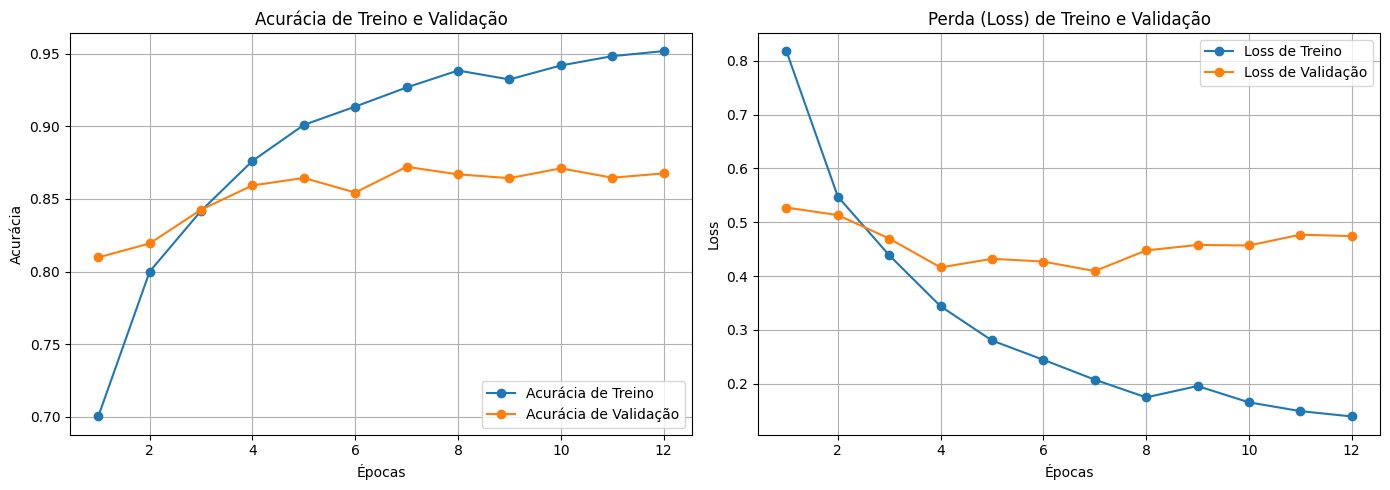

In [13]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, 'o-', label='Acurácia de Treino')
plt.plot(epochs_range, val_acc, 'o-', label='Acurácia de Validação')
plt.title('Acurácia de Treino e Validação')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.grid(True)
plt.legend(loc='lower right')
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, 'o-', label='Loss de Treino')
plt.plot(epochs_range, val_loss, 'o-', label='Loss de Validação')
plt.title('Perda (Loss) de Treino e Validação')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.grid(True)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

In [14]:
y_pred_probs = model_espectograma_aug.predict(test_ds)

y_pred_indices = np.argmax(y_pred_probs, axis=1)

# Extract true labels from test_ds
y_true_indices = []
for _, labels in test_ds:
	y_true_indices.extend(labels.numpy())
y_true_indices = np.array(y_true_indices)

91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step


2025-09-25 00:18:57.600847: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [15]:
print("--- Relatório de Classificação ---")

# Gera o relatório com precisão, recall, f1-score e suporte
# Usa os nomes das classes do label_encoder treinado anteriormente
report = classification_report(y_true_indices, y_pred_indices, target_names=CLASS_NAMES)

print(report)

--- Relatório de Classificação ---
              precision    recall  f1-score   support

          on       0.89      0.84      0.87       396
         off       0.85      0.87      0.86       402
          go       0.82      0.77      0.79       402
   _unknown_       0.72      0.79      0.76       466
          no       0.85      0.83      0.84       405
        stop       0.91      0.91      0.91       411
   _silence_       1.00      0.98      0.99       408

    accuracy                           0.86      2890
   macro avg       0.86      0.86      0.86      2890
weighted avg       0.86      0.86      0.86      2890



--- Matriz de Confusão ---


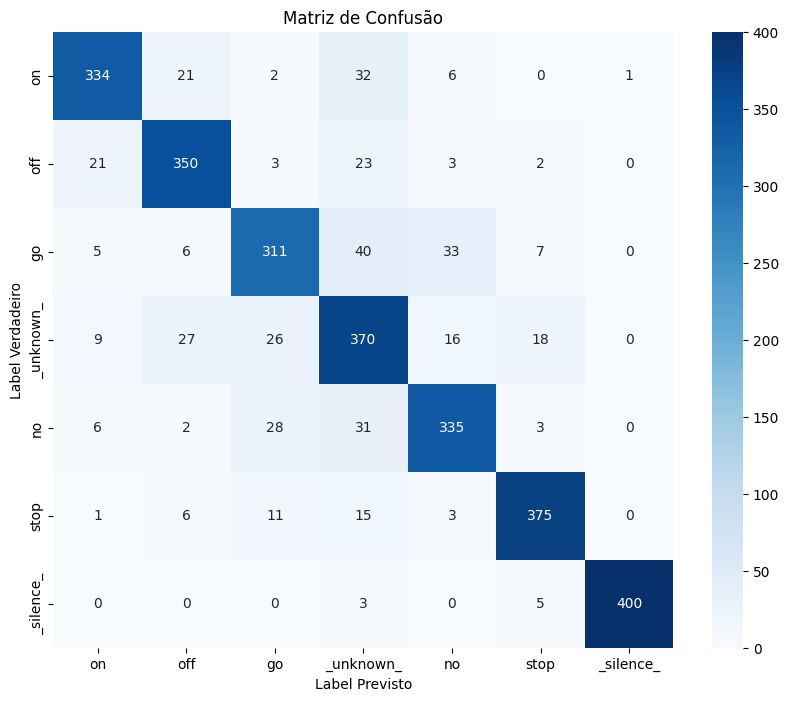

In [16]:
print("--- Matriz de Confusão ---")

# Calcula a matriz de confusão
cm = confusion_matrix(y_true_indices, y_pred_indices)

# Plota a matriz de confusão usando um heatmap do Seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,          # Mostra os números dentro das células
    fmt='d',             # Formata os números como inteiros
    cmap='Blues',        # Esquema de cores
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)

plt.title('Matriz de Confusão')
plt.ylabel('Label Verdadeiro')
plt.xlabel('Label Previsto')
plt.show()

In [17]:
model_espectograma_aug.save("../models/model_espectograma_aug.keras")

## Gerando modelo .tflite (int8):

In [9]:
keras_model = tf.keras.models.load_model("../models/model_espectograma_aug.keras")

converter = tf.lite.TFLiteConverter.from_keras_model(keras_model)

In [11]:
print("\nIniciando conversão com quantização de Inteiros (INT8)...")

# Crie um gerador que fornece amostras do seu dataset
# ATENÇÃO: Adapte `representative_ds` para carregar seus dados!
# Ele precisa ter o mesmo formato/shape que a entrada do seu modelo.
def representative_data_gen():
    # Use, por exemplo, 100 amostras do seu dataset de treino
    # O 'take(100)' pega 100 lotes. Se seu lote for de 32, serão 3200 amostras.
    # Para áudio, o formato pode ser (batch, tempo, features) ou (batch, altura, largura, canais) para espectrogramas.
    for input_value, _ in train_ds.take(100):
        yield [input_value]


converter.representative_dataset = representative_data_gen # Descomente quando tiver o 'train_ds'
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8  # ou tf.uint8
converter.inference_output_type = tf.int8 # ou tf.uint8
tflite_model_int8 = converter.convert()

with open("../models/model_espectograma_int8.tflite", 'wb') as f:
    f.write(tflite_model_int8)
print(f"Modelo com INT8 Quantization salvo em ../models/model_espectograma_int8.tflite")


Iniciando conversão com quantização de Inteiros (INT8)...
INFO:tensorflow:Assets written to: /tmp/tmp3wldywdo/assets


INFO:tensorflow:Assets written to: /tmp/tmp3wldywdo/assets


Saved artifact at '/tmp/tmp3wldywdo'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 28, 1025, 1), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 7), dtype=tf.float32, name=None)
Captures:
  136080609347536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136080805430544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136080805456432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136080805458544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136080805451856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136080805454144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136080805453616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136080805682816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136080805686864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136080805688624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136080805685104

/home/rolds/Documents/Projects/KeyWord Spotting Wonder/Keyword-Spotting-on-Raspberry-Pi-Zero-2W/dev-env/lib/python3.10/site-packages/tensorflow/lite/python/convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
W0000 00:00:1758771008.847838   13523 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1758771008.847848   13523 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
2025-09-25 00:30:08.847949: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmp3wldywdo
2025-09-25 00:30:08.848586: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2025-09-25 00:30:08.848592: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmp3wldywdo
2025-09-25 00:30:08.855933: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2025-09-25 00:30:08.924823: I tensorflow/cc/saved_model

Modelo com INT8 Quantization salvo em ../models/model_espectograma_int8.tflite


fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8


## Testing .tflite model (int8):

In [20]:
TFLITE_MODEL_PATH = Path('../models/model_espectograma_int8.tflite')

In [21]:
print(f"Carregando modelo TFLite de: {TFLITE_MODEL_PATH}")
interpreter = tf.lite.Interpreter(model_path=str(TFLITE_MODEL_PATH))
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()[0]
output_details = interpreter.get_output_details()[0]

Carregando modelo TFLite de: ../models/model_espectograma_int8.tflite


/home/rolds/Documents/Projects/KeyWord Spotting Wonder/Keyword-Spotting-on-Raspberry-Pi-Zero-2W/dev-env/lib/python3.10/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [22]:
is_quantized_model = input_details['dtype'] == np.int8 or input_details['dtype'] == np.uint8
if is_quantized_model:
    # Se o modelo for quantizado, precisamos da escala e do ponto zero para converter nossos dados
    input_scale, input_zero_point = input_details['quantization']
    print(f"Modelo é quantizado. Escala: {input_scale}, Ponto Zero: {input_zero_point}")
else:
    print("Modelo não é quantizado (usa float32).")

Modelo é quantizado. Escala: 2.752337694168091, Ponto Zero: -128


In [23]:
print("\n--- Detalhes do Modelo TFLite ---")
print(f"Entrada (Shape): {input_details['shape']}")
print(f"Entrada (Tipo): {input_details['dtype']}")
print(f"Saída (Shape): {output_details['shape']}")
print(f"Saída (Tipo): {output_details['dtype']}")
print("---------------------------------\n")


--- Detalhes do Modelo TFLite ---
Entrada (Shape): [   1   28 1025    1]
Entrada (Tipo): <class 'numpy.int8'>
Saída (Shape): [1 7]
Saída (Tipo): <class 'numpy.int8'>
---------------------------------



In [24]:
y_true = []
y_pred = []
total_samples = 0

print("\nIniciando avaliação no dataset de teste...")
for data_batch, labels_batch in test_ds:
    for i in range(data_batch.shape[0]):
        # Pegar uma única amostra (ainda em float32)
        sample_data_float = data_batch[i].numpy()
        
        # Adicionar a dimensão do lote
        input_tensor_float = np.expand_dims(sample_data_float, axis=0)
        
        # --- !! A MÁGICA ACONTECE AQUI !! ---
        # Se o modelo for quantizado, convertemos o dado de float para int8
        if is_quantized_model:
            # Fórmula de quantização: int_val = (float_val / scale) + zero_point
            input_tensor_quantized = (input_tensor_float / input_scale) + input_zero_point
            # E então convertemos o tipo para int8
            input_tensor = input_tensor_quantized.astype(input_details['dtype'])
        else:
            # Se não for quantizado, usamos o float32 como antes
            input_tensor = input_tensor_float.astype(input_details['dtype'])

        # Definir o tensor de entrada, executar inferência e obter a saída
        interpreter.set_tensor(input_details['index'], input_tensor)
        interpreter.invoke()
        output_data = interpreter.get_tensor(output_details['index'])

        # Se a SAÍDA também for quantizada, precisamos DE-QUANTIZAR de volta para float
        if output_details['dtype'] == np.int8 or output_details['dtype'] == np.uint8:
            output_scale, output_zero_point = output_details['quantization']
            output_data = (output_data.astype(np.float32) - output_zero_point) * output_scale
        
        # Armazenar o rótulo previsto (agora a partir dos valores de-quantizados) e o verdadeiro
        predicted_label_index = np.argmax(output_data)
        y_pred.append(predicted_label_index)
        y_true.append(labels_batch[i].numpy())
        
    total_samples += data_batch.shape[0]
    if (total_samples % 100 == 0) or (total_samples == len(y_true)):
        print(f"Avaliadas {total_samples} amostras...")

print("\nAvaliação concluída.")


Iniciando avaliação no dataset de teste...
Avaliadas 32 amostras...
Avaliadas 64 amostras...
Avaliadas 96 amostras...
Avaliadas 128 amostras...
Avaliadas 160 amostras...
Avaliadas 192 amostras...
Avaliadas 224 amostras...
Avaliadas 256 amostras...
Avaliadas 288 amostras...
Avaliadas 320 amostras...
Avaliadas 352 amostras...
Avaliadas 384 amostras...
Avaliadas 416 amostras...
Avaliadas 448 amostras...
Avaliadas 480 amostras...
Avaliadas 512 amostras...
Avaliadas 544 amostras...
Avaliadas 576 amostras...
Avaliadas 608 amostras...
Avaliadas 640 amostras...
Avaliadas 672 amostras...
Avaliadas 704 amostras...
Avaliadas 736 amostras...
Avaliadas 768 amostras...
Avaliadas 800 amostras...
Avaliadas 832 amostras...
Avaliadas 864 amostras...
Avaliadas 896 amostras...
Avaliadas 928 amostras...
Avaliadas 960 amostras...
Avaliadas 992 amostras...
Avaliadas 1024 amostras...
Avaliadas 1056 amostras...
Avaliadas 1088 amostras...
Avaliadas 1120 amostras...
Avaliadas 1152 amostras...
Avaliadas 1184 amo

In [25]:
print("\n--- Relatório de Classificação ---")
report = classification_report(y_true, y_pred, target_names=CLASS_NAMES)
print(report)


--- Relatório de Classificação ---
              precision    recall  f1-score   support

          on       0.65      0.67      0.66       396
         off       0.50      0.84      0.62       402
          go       0.61      0.65      0.63       402
   _unknown_       0.30      0.44      0.36       466
          no       0.73      0.57      0.64       405
        stop       0.77      0.54      0.64       411
   _silence_       0.79      0.17      0.28       408

    accuracy                           0.55      2890
   macro avg       0.62      0.56      0.55      2890
weighted avg       0.62      0.55      0.54      2890




--- Matriz de Confusão ---


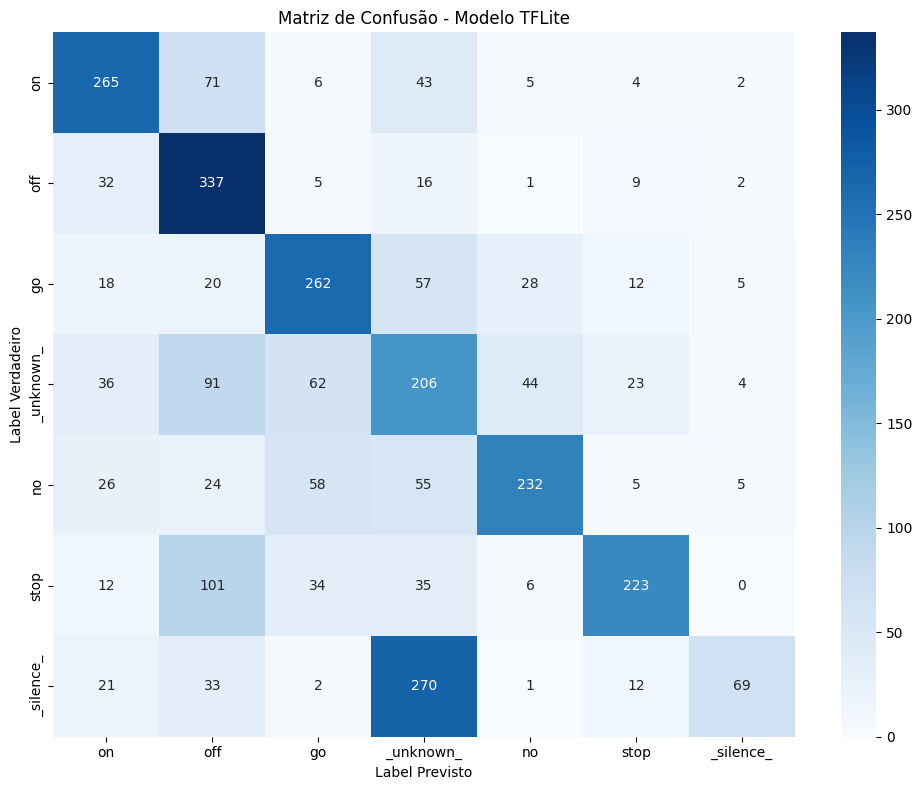

In [26]:
print("\n--- Matriz de Confusão ---")
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)

plt.title('Matriz de Confusão - Modelo TFLite')
plt.ylabel('Label Verdadeiro')
plt.xlabel('Label Previsto')
plt.tight_layout()
plt.show()

## Gerando modelo .tflite (float16):

In [27]:
keras_model = tf.keras.models.load_model("../models/model_espectograma_aug.keras")

converter = tf.lite.TFLiteConverter.from_keras_model(keras_model)

In [ ]:
print("\nIniciando conversão com quantização Float16...")
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_types = [tf.float16]
tflite_model_fp16 = converter.convert()

with open("../models/model_espectograma_fp16.tflite", 'wb') as f:
    f.write(tflite_model_fp16)
print(f"Modelo com Float16 Quantization salvo em ../models/model_espectograma_fp16.tflite")


Iniciando conversão com quantização Float16...
INFO:tensorflow:Assets written to: /tmp/tmp_5353t1b/assets


INFO:tensorflow:Assets written to: /tmp/tmp_5353t1b/assets


Saved artifact at '/tmp/tmp_5353t1b'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 28, 1025, 1), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 7), dtype=tf.float32, name=None)
Captures:
  136077519511168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136077519516096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136077519641184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136077519643296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136077519636608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136077519638896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136077519643472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136077519737552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136077519741600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136077519743360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136077519739840

W0000 00:00:1758771657.592061   13523 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1758771657.592072   13523 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.


Modelo com Float16 Quantization salvo em ../models/model_espectograma_fp16.tflite


2025-09-25 00:40:57.592169: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmp_5353t1b
2025-09-25 00:40:57.592780: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2025-09-25 00:40:57.592785: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmp_5353t1b
2025-09-25 00:40:57.599680: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2025-09-25 00:40:57.668778: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmp_5353t1b
2025-09-25 00:40:57.680988: I tensorflow/cc/saved_model/loader.cc:471] SavedModel load for tags { serve }; Status: success: OK. Took 88821 microseconds.


## Testing .tflite model (float16):

In [32]:
TFLITE_MODEL_PATH = Path('../models/model_espectograma_fp16.tflite')

In [33]:
print(f"Carregando modelo TFLite de: {TFLITE_MODEL_PATH}")
interpreter = tf.lite.Interpreter(model_path=str(TFLITE_MODEL_PATH))
interpreter.allocate_tensors()

Carregando modelo TFLite de: ../models/model_espectograma_fp16.tflite


In [34]:
input_details = interpreter.get_input_details()[0]
output_details = interpreter.get_output_details()[0]

print("\n--- Detalhes do Modelo TFLite ---")
print(f"Entrada (Shape): {input_details['shape']}")
print(f"Entrada (Tipo): {input_details['dtype']}") # Deve ser float32
print(f"Saída (Shape): {output_details['shape']}")
print(f"Saída (Tipo): {output_details['dtype']}") # Deve ser float32


--- Detalhes do Modelo TFLite ---
Entrada (Shape): [   1   28 1025    1]
Entrada (Tipo): <class 'numpy.float32'>
Saída (Shape): [1 7]
Saída (Tipo): <class 'numpy.float32'>


In [35]:
y_true = []
y_pred = []
total_samples = 0

print("Iniciando avaliação no dataset de teste...")
for data_batch, labels_batch in test_ds:
    # Iterar sobre cada amostra no lote
    for i in range(data_batch.shape[0]):
        # Pegar uma única amostra de dado
        sample_data = data_batch[i]
        
        # Adicionar a dimensão do lote (batch dimension) para corresponder ao shape da entrada do modelo
        input_tensor = np.expand_dims(sample_data, axis=0).astype(np.float32)

        # Definir o tensor de entrada, executar inferência e obter a saída
        # Não precisamos de nenhuma conversão manual, o interpretador cuida de tudo.
        interpreter.set_tensor(input_details['index'], input_tensor)
        interpreter.invoke()
        output_data = interpreter.get_tensor(output_details['index'])
        
        # Armazenar o rótulo previsto e o rótulo verdadeiro
        predicted_label_index = np.argmax(output_data)
        y_pred.append(predicted_label_index)
        y_true.append(labels_batch[i].numpy())
        
    total_samples += data_batch.shape[0]
    print(f"Avaliadas {total_samples} amostras...")

print("\nAvaliação concluída.")

Iniciando avaliação no dataset de teste...
Avaliadas 32 amostras...
Avaliadas 64 amostras...
Avaliadas 96 amostras...
Avaliadas 128 amostras...
Avaliadas 160 amostras...
Avaliadas 192 amostras...
Avaliadas 224 amostras...
Avaliadas 256 amostras...
Avaliadas 288 amostras...
Avaliadas 320 amostras...
Avaliadas 352 amostras...
Avaliadas 384 amostras...
Avaliadas 416 amostras...
Avaliadas 448 amostras...
Avaliadas 480 amostras...
Avaliadas 512 amostras...
Avaliadas 544 amostras...
Avaliadas 576 amostras...
Avaliadas 608 amostras...
Avaliadas 640 amostras...
Avaliadas 672 amostras...
Avaliadas 704 amostras...
Avaliadas 736 amostras...
Avaliadas 768 amostras...
Avaliadas 800 amostras...
Avaliadas 832 amostras...
Avaliadas 864 amostras...
Avaliadas 896 amostras...
Avaliadas 928 amostras...
Avaliadas 960 amostras...
Avaliadas 992 amostras...
Avaliadas 1024 amostras...
Avaliadas 1056 amostras...
Avaliadas 1088 amostras...
Avaliadas 1120 amostras...
Avaliadas 1152 amostras...
Avaliadas 1184 amos

2025-09-25 00:44:23.552727: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [36]:
print("\n--- Relatório de Classificação ---")
report = classification_report(y_true, y_pred, target_names=CLASS_NAMES)
print(report)


--- Relatório de Classificação ---
              precision    recall  f1-score   support

          on       0.88      0.84      0.86       396
         off       0.85      0.87      0.86       402
          go       0.82      0.77      0.80       402
   _unknown_       0.71      0.76      0.73       466
          no       0.83      0.83      0.83       405
        stop       0.90      0.91      0.91       411
   _silence_       1.00      0.98      0.99       408

    accuracy                           0.85      2890
   macro avg       0.86      0.85      0.85      2890
weighted avg       0.85      0.85      0.85      2890




--- Matriz de Confusão ---


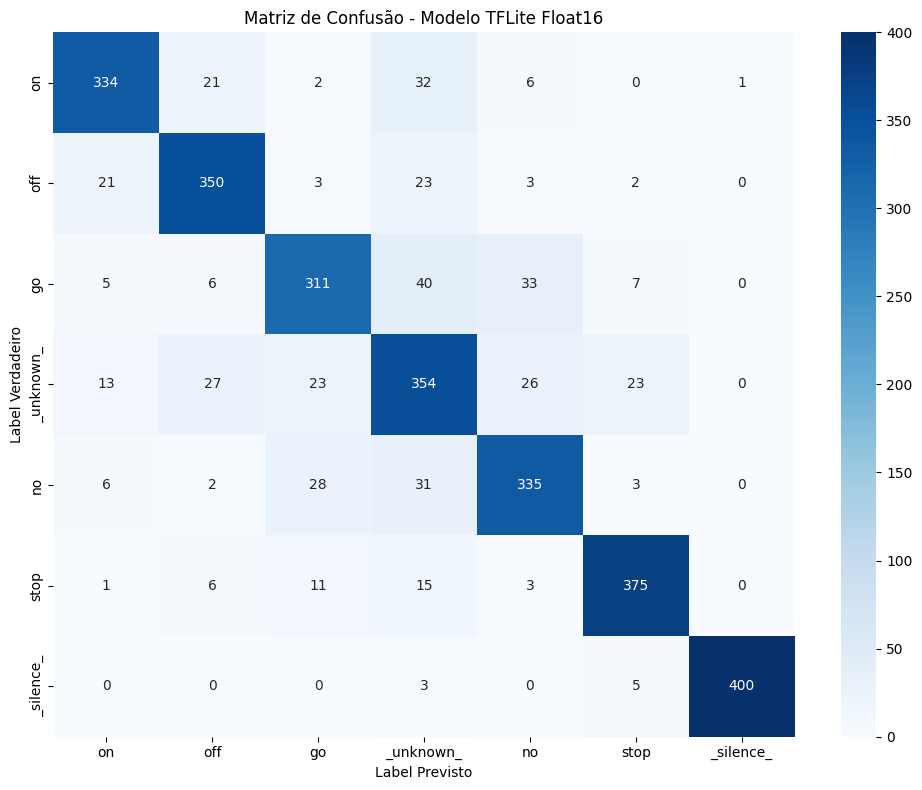

In [37]:
print("\n--- Matriz de Confusão ---")
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)

plt.title('Matriz de Confusão - Modelo TFLite Float16')
plt.ylabel('Label Verdadeiro')
plt.xlabel('Label Previsto')
plt.tight_layout()
plt.show()